**Table of contents**<a id='toc0_'></a>    
- [Coincidence plots](#toc1_)    
  - [General information](#toc1_1_)    
  - [Poisson case](#toc1_2_)    
  - [Bunched case](#toc1_3_)    
  - [Antibunched case](#toc1_4_)    
  - [Simulations](#toc1_5_)    
    - [Continuous case](#toc1_5_1_)    
      - [Only fluorescence and excitation](#toc1_5_1_1_)    
      - [With dSTORM](#toc1_5_1_2_)    
        - [zoomed out](#toc1_5_1_2_1_)    
        - [zoomed in 1 of 2](#toc1_5_1_2_2_)    
        - [zoomed in 2 of 2](#toc1_5_1_2_3_)    
    - [Pulsed case](#toc1_5_2_)    
      - [Only fluorescence and excitation](#toc1_5_2_1_)    
      - [With dSTORM](#toc1_5_2_2_)    
        - [Normalized to the peak height](#toc1_5_2_2_1_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Coincidence plots](#toc0_)

In [1]:
import warnings

import numpy as np

import fluopy.emissions as em
import fluopy.fcs as fcs_p
import fluopy.figure as fi
import fluopy.fluorophores as fl
import fluopy.simulation as si
import fluopy.transitions as tr

%load_ext autoreload
%autoreload 2


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

## <a id='toc1_1_'></a>[General information](#toc0_)
If the bin_width is too large, the bunching/antibunching information gets lost. \
If tau_max is too large, only very few photon pairs contribute to the bin. I.e., the number of contributing pairs gets smaller the further away from 0. One can adjust for this by normalizing using T (the maximum time) and the bins as hist / (T-abs(bins)). This corrects for finite window effects.

## <a id='toc1_2_'></a>[Poisson case](#toc0_)

array([[<Axes: xlabel='$\\tau$ (s)', ylabel='$g^{(2)}(\\tau)$'>]],
      dtype=object)

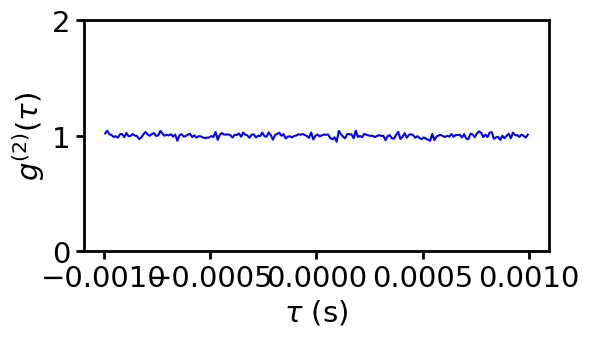

In [2]:
rng = np.random.default_rng(0)
intervals = rng.exponential(scale=1e-5, size=10000)
times = np.cumsum(intervals)
hist, bins_centers = fcs_p.coincidence(times, tau_max=1e-3, bin_width=1e-5, seed=rng)
fi.universal_figure(
    type_="line",
    data=[bins_centers, hist],
    xlabel=r"$\tau$ (s)",
    ylabel=r"$g^{(2)}(\tau)$",
    ylim=[0, 2],
)

## <a id='toc1_3_'></a>[Bunched case](#toc0_)
artificially bunched, can exceed 2 on the y axis

array([[<Axes: xlabel='$\\tau$ (s)', ylabel='$g^{(2)}(\\tau)$'>]],
      dtype=object)

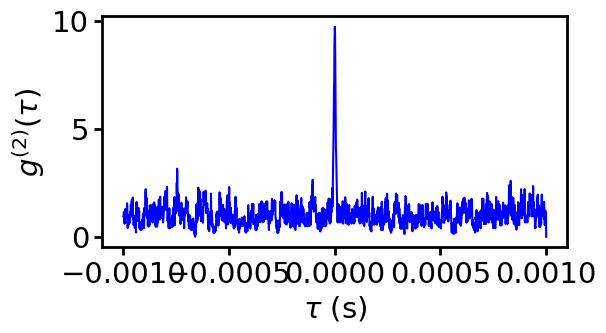

In [3]:
rng = np.random.default_rng(1)
times = []
t = 0.0
duration = 1e-2
n_photons = 20000
while t < duration and len(times) < n_photons:
    burst_size = rng.poisson(10)  # size of each burst
    burst_intervals = rng.exponential(scale=1e-6, size=burst_size)
    for dt in burst_intervals:
        t += dt
        times.append(t)
    t += rng.exponential(scale=1e-4)  # pause between bursts

times = np.array(times)

hist, bin_centers = fcs_p.coincidence(times, tau_max=1e-3, bin_width=1e-6, seed=rng)
fi.universal_figure(
    type_="line",
    data=[bin_centers, hist],
    xlabel=r"$\tau$ (s)",
    ylabel=r"$g^{(2)}(\tau)$",
)

## <a id='toc1_4_'></a>[Antibunched case](#toc0_)

array([[<Axes: xlabel='$\\tau$ (s)', ylabel='$g^{(2)}(\\tau)$'>]],
      dtype=object)

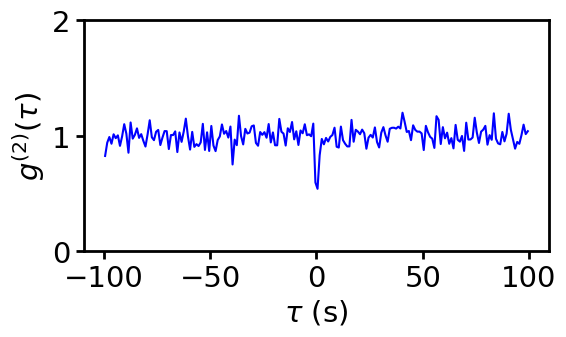

In [4]:
rng = np.random.default_rng(2)
fluorescence_lifetimes = rng.exponential(scale=1, size=1000)
s0_lifetimes = rng.exponential(scale=1, size=1000)
times_of_cycle = fluorescence_lifetimes + s0_lifetimes
times = np.cumsum(times_of_cycle)

hist, bin_centers = fcs_p.coincidence(times, tau_max=1e2, bin_width=1e0, seed=rng)
fi.universal_figure(
    type_="line",
    data=[bin_centers, hist],
    xlabel=r"$\tau$ (s)",
    ylabel=r"$g^{(2)}(\tau)$",
    ylim=[0, 2],
)

## <a id='toc1_5_'></a>[Simulations](#toc0_)

In [6]:
def prepare_transition_set_ofret(number_fluorophores, distance):
    fluorophores = fl.construct_fluorophores(
        name="cy5_dna", distance=distance, count=number_fluorophores, shape="square"
    )
    fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

    transitions = fluorophore_system.load_transitions(
        summarize=True,
        irradiance=2.5,
        wavelength=640,
        bleaching=False,
        energy_transfer=True,
        dstorm=True,
        dstorm_parameters={"reducing_agent": "mea", "concentration": 100, "ph": 7.5},
        energy_transfer_parameters={
            "overwrite": {"off": [1, 0.0001]},
            "exclude": ["s0"],
        },
    )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()

    return transition_set

### <a id='toc1_5_1_'></a>[Continuous case](#toc0_)

#### <a id='toc1_5_1_1_'></a>[Only fluorescence and excitation](#toc0_)
1 fluorophore. shows antibunching dip at x = 0

array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

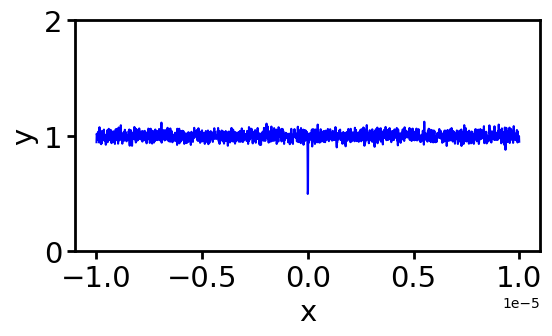

In [7]:
rng = np.random.default_rng(4)
transition_set = prepare_transition_set_ofret(1, 1)
transition_set = transition_set.filter_by_identity(np.arange(2, 11))
transition_set.finalize()

simu = si.Simulation(transition_set)
simu.run(size=1e5, seed=rng)
times = simu.time_series[2::2]

hist, bin_centers = fcs_p.coincidence(times, tau_max=1e-5, bin_width=1e-8, seed=rng)
fi.universal_figure(type_="line", data=[bin_centers, hist], ylim=[0, 2])

#### <a id='toc1_5_1_2_'></a>[With dSTORM](#toc0_)

In [8]:
rng = np.random.default_rng(6)
transition_set = prepare_transition_set_ofret(1, 1)
transition_set.finalize()

simu = si.Simulation(transition_set)
simu.run(size=2e6, seed=rng)
emis = em.Emissions(frame_time="1ms", bandpass=[665, 731], seed=rng)
emis.extract(simu)
times = emis.event_time_points

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.69e-12.
 This was estimated using the highest possible rate which occurs for example in state combination [1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.


This is a blinking fluorophore. Coincidence plots compare the correlation to the expected correlation if the photon source is Poisson with a certain average rate. The blinking fluorophore has long times with no emission, hence the average is much lower than in a coherent photon source. Thats why the y axis may exceed 2 by far. There will be bunching on some time scales (ON periods) and antibunching on very small time scales (S0 lifetime).

##### <a id='toc1_5_1_2_1_'></a>[zoomed out](#toc0_)

array([[<Axes: xlabel='$\\tau$ (s)', ylabel='$g^{(2)}(\\tau)$'>]],
      dtype=object)

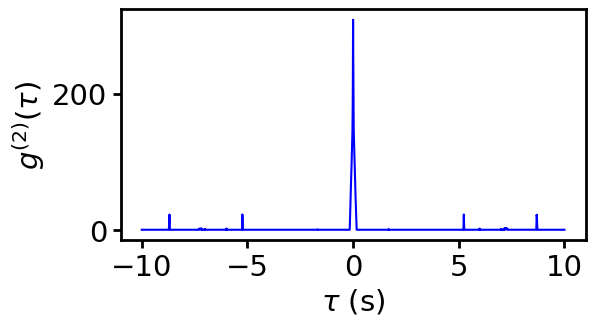

In [9]:
rng = np.random.default_rng(7)
hist, bin_centers = fcs_p.coincidence(times, tau_max=1e1, bin_width=1e-3, seed=rng)
fi.universal_figure(
    type_="line",
    data=[bin_centers, hist],
    xlabel=r"$\tau$ (s)",
    ylabel=r"$g^{(2)}(\tau)$",
)

##### <a id='toc1_5_1_2_2_'></a>[zoomed in 1 of 2](#toc0_)

array([[<Axes: xlabel='$\\tau$ (s)', ylabel='$g^{(2)}(\\tau)$'>]],
      dtype=object)

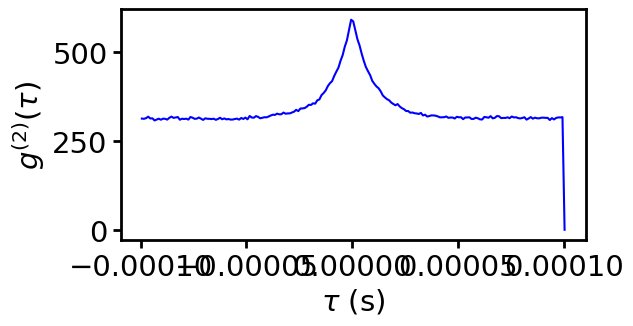

In [10]:
rng = np.random.default_rng(8)
hist, bin_centers = fcs_p.coincidence(times, tau_max=1e-4, bin_width=1e-6, seed=rng)
fi.universal_figure(
    type_="line",
    data=[bin_centers, hist],
    xlabel=r"$\tau$ (s)",
    ylabel=r"$g^{(2)}(\tau)$",
)

##### <a id='toc1_5_1_2_3_'></a>[zoomed in 2 of 2](#toc0_)

array([[<Axes: xlabel='$\\tau$ (s)', ylabel='$g^{(2)}(\\tau)$'>]],
      dtype=object)

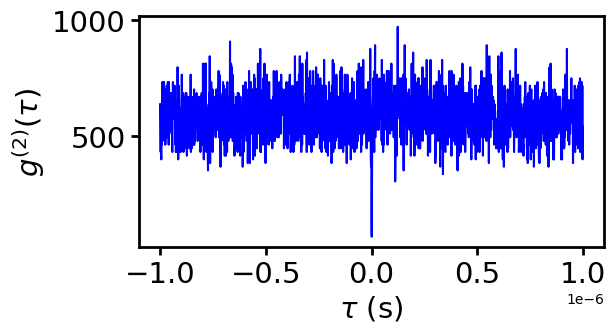

In [11]:
rng = np.random.default_rng(9)
hist, bin_centers = fcs_p.coincidence(times, tau_max=1e-6, bin_width=1e-9, seed=rng)
fi.universal_figure(
    type_="line",
    data=[bin_centers, hist],
    xlabel=r"$\tau$ (s)",
    ylabel=r"$g^{(2)}(\tau)$",
)

### <a id='toc1_5_2_'></a>[Pulsed case](#toc0_)

#### <a id='toc1_5_2_1_'></a>[Only fluorescence and excitation](#toc0_)

In [13]:
rng = np.random.default_rng(10)
transition_set = prepare_transition_set_ofret(1, 3)
transition_set = transition_set.filter_by_identity(np.arange(2, 11))
transition_set.finalize()
emis = em.Emissions(frame_time="1ms", bandpass=[665, 731], seed=rng)
Da, D, lifetimes_all, _ = emis.tcspc(
    transition_set,
    number_pulses=1e6,
    excitation_rates={"cy5_dna": 3.75e9},
    time_between_pulses=12.5e-9,
    store_time_points=True,
)
times = emis.event_time_points

the last frame (of index 0.013) has 5.00e-01 times the pulses of other frames.


array([[<Axes: xlabel='$\\tau$ (s)', ylabel='$g^{(2)}(\\tau)$'>]],
      dtype=object)

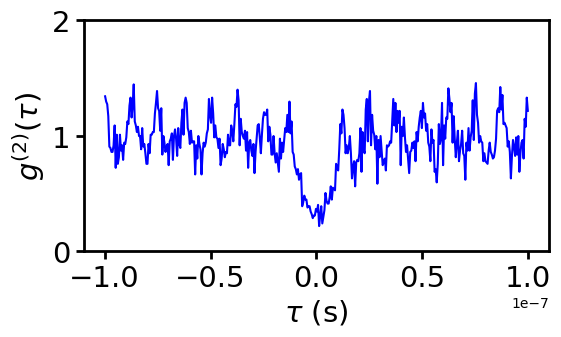

In [14]:
rng = np.random.default_rng(11)
hist, bin_centers = fcs_p.coincidence(
    times[:200000], tau_max=1e-7, bin_width=5e-10, seed=rng
)
fi.universal_figure(
    type_="line",
    data=[bin_centers, hist],
    xlabel=r"$\tau$ (s)",
    ylabel=r"$g^{(2)}(\tau)$",
    ylim=[0, 2],
)

#### <a id='toc1_5_2_2_'></a>[With dSTORM](#toc0_)

In [16]:
rng = np.random.default_rng(11)
transition_set = prepare_transition_set_ofret(1, 3)
transition_set.finalize()
emis = em.Emissions(frame_time="1ms", bandpass=[665, 731], seed=rng)
Da, D, lifetimes_all, _ = emis.tcspc(
    transition_set,
    number_pulses=1e8,
    excitation_rates={"cy5_dna": 3.75e9},
    time_between_pulses=12.5e-9,
    store_time_points=True,
)
times = emis.event_time_points

the last frame (of index 1.25) has 0.00e+00 times the pulses of other frames.


array([[<Axes: xlabel='$\\tau$ (s)', ylabel='$g^{(2)}(\\tau)$'>]],
      dtype=object)

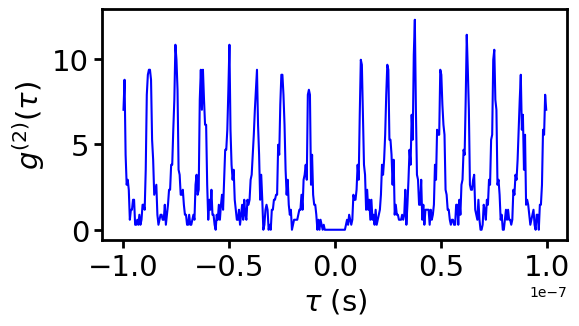

In [17]:
rng = np.random.default_rng(12)
hist, bin_centers = fcs_p.coincidence(
    times[:200000], tau_max=1e-7, bin_width=5e-10, seed=rng
)
fi.universal_figure(
    type_="line",
    data=[bin_centers, hist],
    xlabel=r"$\tau$ (s)",
    ylabel=r"$g^{(2)}(\tau)$",
)

##### <a id='toc1_5_2_2_1_'></a>[Normalized to the peak height](#toc0_)

array([[<Axes: xlabel='$\\tau$ (s)', ylabel='$g^{(2)}(\\tau)$'>]],
      dtype=object)

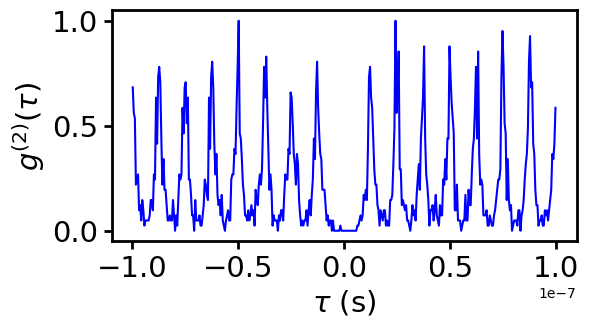

In [18]:
rng = np.random.default_rng(13)
hist, bin_centers = fcs_p.coincidence(
    times[:200000], tau_max=1e-7, bin_width=5e-10, seed=rng
)
hist = hist / np.max(hist)
fi.universal_figure(
    type_="line",
    data=[bin_centers, hist],
    xlabel=r"$\tau$ (s)",
    ylabel=r"$g^{(2)}(\tau)$",
)